# Определение наилучшей дислокации единственного подразделения (BLP)

Первой и простейшей задачей размещения подразделений пожарной охраны является Задача определения наилучшей дислокации единственного подразделения (далее – **BLP**, от англ. *Best Location Problem*).

В общем виде процесс решения задачи BLP можно представить следующим образом:

```{mermaid}
flowchart LR

  model("**МОДЕЛИРОВАНИЕ
          ПАРАМЕТРОВ
          ПРИБЫТИЯ**")
  
  result["**РЕЗУЛЬТАТЫ**"]

  analyze("**АНАЛИЗ**
        ---
        Время прибытия
        ---
        Индекс прикрытия")

  metrics["**МЕТРИКИ**"]

  blp_algs["**ЭВРИСТИЧЕСКИЕ АЛГОРИТМЫ BLP**
        ---
        ADD
        ---
        Полный перебор, HC, MSA, ABC"]

  blp("**ВЫБОР ДИСЛОКАЦИИ**")
        
  model --> result
  metrics --> analyze
  result --> analyze
  analyze --> blp
  blp_algs --> blp
  blp --> model

```

Поиск наилучшей дислокации подразумевает выдвижение гипотез о размещении подразделений и моделирование параметров реагирования прибытия, после чего на основании проведенного анализа делается вывод о том, насколько предложенное размещение подразделений оптимально.

В **Генезис** реализованы следующие алгоритмы решения задачи BLP:

- Рекомендуемый:
  - `genesis.lscp.LSCP_ADD` Алгоритм жадного добавления (ADD) - *рекомендуемый*,
- Прочие:
  - `genesis.best_points.BestNodesFull` Полный перебор
  - `genesis.best_points.BestNodeHillClimbing` Скалолаз (HC)
  - `genesis.best_points.BestNodeHillClimbing_maxMean` Скалолаз (HC), модификация для метрик максимальное время + среднее время
  - `genesis.best_points.BestNodeMonkey` Алгоритм обезьяньего поиска (MSA)
  - `genesis.best_points.BestNodeBee` Алгоритм искусственной пчелиной колонии (ABC)

Реализован также ряд дополнительных алгоритмов описываемых в разделе **Для разработчиков**.

## Загрузка исходных данных

In [1]:
import numpy as np
import osmnx as ox
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import genesis as genesis


# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\ngenesis:', genesis.__version__,
      )

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
genesis: 0.1.031


In [ ]:
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


# 1. Загрузка исходных данных
## Загрузка ГДС
G = ox.load_graphml('data/kemerovo/gds.ml')

## Установка скоростного режима
set_graph_travel_times(
    G,
    speeds=DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)

## Упрощение графа (уменьшение количества узлов)
G = ox.simplification.simplify_graph(G)

## Загрузка границ города
borders = gpd.read_file('data/kemerovo/borders.gpkg')

## Загрузка пожарных подразделений
units = gpd.read_file('data/kemerovo/fire_units.gpkg')
### Сопоставление пожарных подразделений с ближайшими узлами ГДС
units['node'] = ox.distance.nearest_nodes(G, units.geometry.x, units.geometry.y)
### Формирование словаря подразделений для передачи алгоритму
units_dict = {k:v for k,v in zip(units['node'], units['name'])}

## Загрузка зданий
buildings = gpd.read_file('data/kemerovo/buildings.gpkg')
### Сопоставление зданий с ближайшими узлами ГДС
centroids = ox.projection.project_gdf(buildings).geometry.centroid
buildings['node'] = ox.distance.nearest_nodes(ox.project_graph(G), 
                                              centroids.x,
                                              centroids.y
                                              )

## Рекомендуемый способ: Алгоритм жадного добавления

Рекомендуемым способом является использование алгоритма жадного добавления **ADD**: `genesis.lscp.LSCP_ADD`.

Данный подход универсален и может быть применен к решению задач **BLP**, **MCLP**, **LSCP**.

Он основан на идее определения точки при размещении пожарного депо в которой обеспечивается заданное время прибытия к как можно большему количеству объектов защиты. При расчете используется моделирование параметров прибытия подразделений пожарной охраны с использованием матрицы прибытия `genesis.states.ArrivalTimeMatrixState`.

### Матрица прибытия {.unnumbered}

Матрица прибытия - таблица в которой строками являются идентификаторы узлов зданий, столбцами - идентификаторы узлов графа из которых можно попасть в каждое из зданий, в ячейках хранится числовое значение времени прибытия из каждого узла графа к каждому из зданий, либо значение `NaN`, означающее, что из узла $N_n$ нельзя попасть к зданию $B_n$, за заданное время (@tbl-atm-example-2).

|  | $N_1$ | $N_2$ | $N_3$ | $N_4$ | $N_5$ |
| - | ---- | ----- | ----- | --- | ----- |
| $B_1$ | 3,1 | 4,2 | 1,5 | 13,2 | 7,5 |
| $B_2$ | 6,6 | `NaN` | 14,2 | 7,2 | 3,3 |
| $B_3$ | 4,2 | 6,1 | `NaN` | 6,4 | 12,3 |
| $B_4$ | `NaN` | 12,9 | 4,5 | `NaN` | `NaN` |
| $B_5$ | 6,3 | `NaN` | `NaN` | `NaN` | 2,1 |
: Пример матрицы прибытия {#tbl-atm-example-2}

В приведенном примере (@tbl-atm-example-2) можно заметить, что узлом из которого можно попасть за 10 минут в наибольшее количество зданий является узел $N_1$ (4 здания) - этот узел и является предпочтительным для размещения пожарного депо.

Матрица рассчитывается при помощи функции `genesis.states.get_atm`:

In [ ]:
from genesis.states import get_atm

## Расчет матрицы прибытия
matrix = get_atm(G,
                 data             = buildings,
                 data_sample_size = 2000,
                 cutoff           = 10,
                 )

|########################################| 100.0%


### Расчет без учета имеющихся подразделений {.unnumbered}

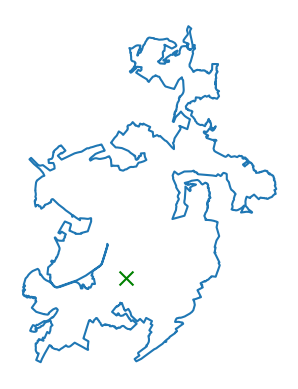

In [ ]:
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция остановки
stop_case = lambda dynamic_nodes, **kwargs: len(dynamic_nodes) >= 1      # Расчет проводится для 1 подразделения

## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = state,
    matrix              = matrix,
    metric_function     = metric,
    stop_case_function  = stop_case,
)


# 3. Расчет BLP
best_nodes, best_metric = add(
        env          = G,
    )


# 4. Печать результатов
## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
ax = borders.boundary.plot()
g_nodes.loc[best_nodes.keys()].plot(ax=ax, color='green', marker='x', markersize=100)
ax.set_axis_off()
plt.show()

### Расчет с учетом имеющихся подразделений {.unnumbered}

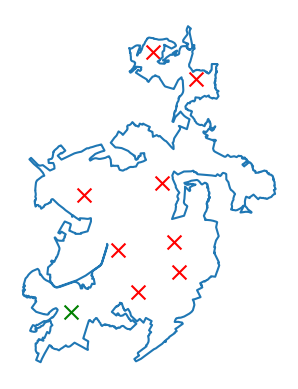

In [ ]:
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция остановки
stop_case = lambda dynamic_nodes, **kwargs: len(dynamic_nodes) >= 1      # Расчет проводится для 1 подразделения

## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = state,
    matrix              = matrix,
    metric_function     = metric,
    stop_case_function  = stop_case,
)


# 3. Расчет BLP
best_nodes, best_metric = add(
        env          = G,
        static_nodes = units_dict,  # Размещение существующих подразделений пожарной охраны
    )


# 4. Печать результатов
## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
ax = borders.boundary.plot()
g_nodes.loc[best_nodes.keys()].plot(ax=ax, color='green', marker='x', markersize=100)
g_nodes.loc[units_dict.keys()].plot(ax=ax, color='red', marker='x', markersize=100)
ax.set_axis_off()
plt.show()

:::{.callout-important}
### Важно 

Алгоритм моделирования `ArrivalTimeMatrixState(matrix)` используется в `LSCP_ADD` только в том случае, если при расчете матрицы прибытия **не было указано** ограничение времени прибытия `cutoff`.

Если же в функции `get_atm` **было указано** ограничение времени прибытия `cutoff` (так как в примере выше), то следует использовать алгоритм моделирования `FirstArrivalUnitState()`

:::

## Дополнительные способы

### Полный перебор {.unnumbered}

Для небольших ГДС допустимо применение полного перебора всех узлов. Этот способ позволяет получить точное решение, в отличие от эвристических алгоритмов. Однако он требует значительных затрат времени.

|########################################| 100.0%
3323563003 30.38183804524501


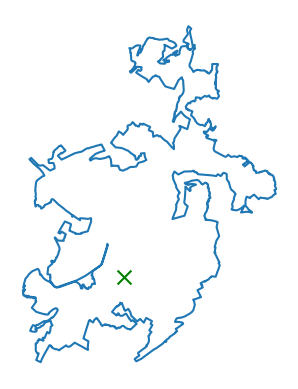

In [11]:
from genesis.best_points import BestNodesFull
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding
from genesis.utils import Progressbar


# 1. Подготовка исходных данных
## Полный расчет слишком длителен, поэтому для примера работы
## выбираем 100 случайных узлов графа (для расчета за приемлемое время)
g_nodes_sample = ox.graph_to_gdfs(G, edges=False).sample(100)
g_nodes_sample = set(g_nodes_sample.index)


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10

## Функция выполняемая в конце расчета каждого узла. В данном случе - строка выполнения
node_calc_end = Progressbar(len(g_nodes_sample))

## Сборка и инициализация алгоритма полного перебора
full = BestNodesFull(
    state_function      = state,
    metric_function     = metric,
    node_calc_end_function = node_calc_end,
)



# 3. Расчет полным перебором узлов g_nodes_sample
best_node, best_metric = full(
        env          = G,
        points_list = g_nodes_sample,
    )


# 4. Печать результатов
print(best_node, best_metric)
## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
ax = borders.boundary.plot()
g_nodes.loc[[best_node]].plot(ax=ax, color='green', marker='x', markersize=100)
ax.set_axis_off()
plt.show()

### Скалолаз (HC), модификация для метрик максимальное время + среднее время {.unnumbered}

Это алгоритм локального поиска, поэтому для крупных ГДС дает слишком приближенное решение. Однако, он работает быстро и дает точное решение при поиске лучшего размещения в пределах некоторой ограниченной области. Поэтому он может быть использован как алгоритм дополнительной, "чистовой", обработки.

390616533 19.79207648191979


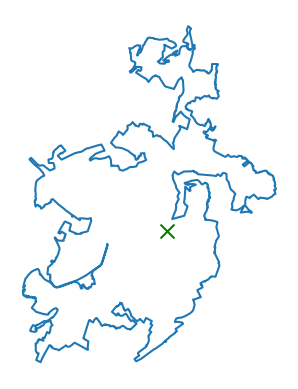

In [12]:
from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean 
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import ArrivalTimeBuilding



# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = ArrivalTimeBuilding(buildings) # Метрика среднего времени прибытия к зданиям

## Сборка и инициализация алгоритма скалолаз + max + mean
hcmm = BestNodeHillClimbing_HD_Max_Mean(
    state_function      = state,
    metric_function     = metric,
)



# 3. Расчет скалолаз + max + mean
best_node, best_metric = hcmm(
        env          = G,
    )


# 4. Печать результатов
print(best_node, best_metric)
## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
ax = borders.boundary.plot()
g_nodes.loc[[best_node]].plot(ax=ax, color='green', marker='x', markersize=100)
ax.set_axis_off()
plt.show()

### Алгоритм обезьяньего поиска (MSA) {.unnumbered}

Глобальный прыжок 0 , метрика 21.06799982772208
Локальный прыжок -1 , метрика 18.56060908094667
Локальный прыжок -1 , метрика 17.177761746458103
Локальный прыжок -1 , метрика 16.36060628093831
Локальный прыжок 0 , метрика 16.36060628093831
Локальный прыжок 1 , метрика 16.36060628093831
Локальный прыжок -1 , метрика 15.998494117580094
Локальный прыжок 0 , метрика 15.998494117580094
Локальный прыжок 1 , метрика 15.998494117580094
Локальный прыжок 2 , метрика 15.998494117580094
Локальный прыжок 3 , метрика 15.998494117580094
Локальный прыжок -1 , метрика 15.573708044425976
Локальный прыжок 0 , метрика 15.573708044425976
Локальный прыжок 1 , метрика 15.573708044425976
Локальный прыжок 2 , метрика 15.573708044425976
Локальный прыжок 3 , метрика 15.573708044425976
Локальный прыжок -1 , метрика 15.564097358932415
Локальный прыжок 0 , метрика 15.564097358932415
Локальный прыжок 1 , метрика 15.564097358932415
Локальный прыжок 2 , метрика 15.564097358932415
Локальный прыжок -1 , метрика 15.47195

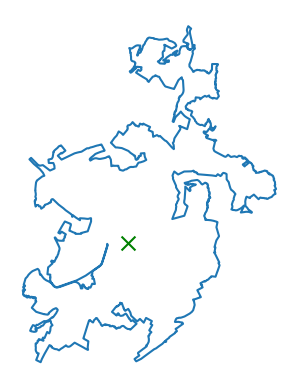

In [10]:
from genesis.best_points import BestNodeMonkey 
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import ArrivalTimeBuilding



# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = ArrivalTimeBuilding(buildings) # Метрика среднего времени прибытия к зданиям

## Функции контроля хода выполнения
jump_f = lambda global_jump_number, best_metric, **kwargs: print('Глобальный прыжок', global_jump_number, ', метрика', best_metric)
jump_fl = lambda local_jump_number, best_metric, **kwargs: print('Локальный прыжок', local_jump_number, ', метрика', best_metric)

## Сборка и инициализация алгоритма MSA
msa = BestNodeMonkey(
    state_function             = state,
    metric_function            = metric,
    after_global_jump_function = jump_f,
    after_local_jump_function  = jump_fl,
    local_jump_max_distance    = 500,          # Расстояние локального прыжка (в метрах)
    local_jumps_count          = 5,            # Количество локальных прыжков
)



# 3. Расчет MSA
best_node, best_metric = msa(
        env          = ox.project_graph(G),     # Для подачи ГДС в алгоритм MSA необходимо перепроецировать его в локальную СК
    )


# 4. Печать результатов
print(best_node, best_metric)
## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
ax = borders.boundary.plot()
g_nodes.loc[[best_node]].plot(ax=ax, color='green', marker='x', markersize=100)
ax.set_axis_off()
plt.show()

:::{.callout-note}

Для подачи ГДС в алгоритм MSA необходимо перепроецировать его в локальную СК:

`G = ox.project_graph(G)`

:::

### Алгоритм искусственной пчелиной колонии (ABC) {.unnumbered}

1668774988 15.732398978859422


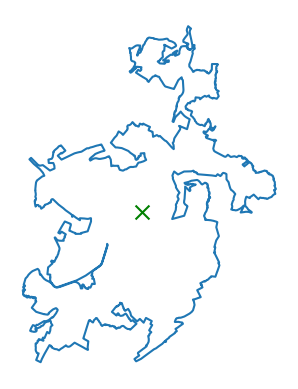

In [9]:
from genesis.best_points import BestNodeBee 
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import ArrivalTimeBuilding



# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = ArrivalTimeBuilding(buildings) # Метрика среднего времени прибытия к зданиям

## Сборка и инициализация алгоритма ABC
abc = BestNodeBee(
    state_function      = state,
    metric_function     = metric,
)



# 3. Расчет ABC
best_node, best_metric = abc(
        env          = G,
    )


# 4. Печать результатов
print(best_node, best_metric)
## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
ax = borders.boundary.plot()
g_nodes.loc[[best_node]].plot(ax=ax, color='green', marker='x', markersize=100)
ax.set_axis_off()
plt.show()

# Тест от Cursor

# Best Points Module Documentation

This module contains algorithms for finding optimal nodes in a graph. Each algorithm implements different search strategies to find nodes that optimize specific metrics.

## NodeMetric

Class for calculating metrics for specific graph nodes.

### Methods

#### `__init__(state_function, metric_function, appr_val=0.95, err_val=None, **kwargs)`

**Parameters:**

- `state_function`: StateBase
  - Function for calculating environment state
- `metric_function`: MetricBase
  - Function for calculating metrics
- `appr_val`: float = 0.95
  - Proportion of graph nodes that should be reachable for the metric to be considered valid
- `err_val`: Any = None
  - Value returned if required proportion of nodes cannot be reached

#### `__call__(env, node, area=None, **kwargs)`

**Parameters:**

- `env`: nx.Graph
  - Road network graph
- `node`: int
  - Node ID for which calculation is performed
- `area`: pd.Series = None
  - Mask of graph nodes. True values mark target nodes for Voronoi forest calculation

## BestNodesFull

Class implementing exhaustive search to find optimal graph nodes.

### Methods

#### `__init__(state_function, metric_function, appr_val=0.95, return_list=False, node_calc_end_function=None, **kwargs)`

**Parameters:**

- `state_function`: StateBase
  - Function for calculating environment state
- `metric_function`: MetricBase
  - Function for calculating metrics
- `appr_val`: float = 0.95
  - Proportion of graph nodes that should be reachable
- `return_list`: bool = False
  - If True, returns list of all best nodes; if False, returns only first one
- `node_calc_end_function`: callable = None
  - Function called after each node calculation

#### `__call__(env, area=None, start_point=None, points_list=None, **kwargs)`

**Parameters:**

- `env`: nx.Graph
  - Road network graph
- `area`: pd.Series = None
  - Mask of graph nodes
- `points_list`: set = None
  - Set of candidate nodes to consider

## BestNodeHillClimbing

Class implementing hill climbing algorithm for finding optimal graph nodes.

### Methods

#### `__init__(state_function, metric_function, appr_val=0.95, all_neighbors=True, node_calc_end_function=None, **kwargs)`

**Parameters:**

- `state_function`: StateBase
  - Function for calculating environment state
- `metric_function`: MetricBase
  - Function for calculating metrics
- `appr_val`: float = 0.95
  - Proportion of graph nodes that should be reachable
- `all_neighbors`: bool = True
  - If True, considers all adjacent nodes; if False, only outgoing ones
- `node_calc_end_function`: callable = None
  - Function called after each node calculation

#### `__call__(env, area=None, start_point=None, points_list=None, **kwargs)`

**Parameters:**

- `env`: nx.Graph
  - Road network graph
- `area`: pd.Series = None
  - Mask of graph nodes
- `start_point`: int = None
  - Starting node ID
- `points_list`: set = None
  - Set of candidate nodes to consider

## BestNodeHillClimbing_maxMean

Class extending BestNodeHillClimbing with combined maximum and mean metrics.

### Methods

#### `__init__(state_function, metric_function=None, appr_val=0.95, all_neighbors=True, **kwargs)`

**Parameters:**

- `state_function`: StateBase
  - Function for calculating environment state
- `metric_function`: MetricBase = None
  - Function for calculating metrics
- `appr_val`: float = 0.95
  - Proportion of graph nodes that should be reachable
- `all_neighbors`: bool = True
  - If True, considers all adjacent nodes

#### `__call__(env, area=None, start_point=None, points_list=None, debug_route=False, node_calc_end_function=None, **kwargs)`

**Parameters:**

- `env`: nx.Graph
  - Road network graph
- `area`: pd.Series = None
  - Mask of graph nodes
- `start_point`: int = None
  - Starting node ID
- `points_list`: set = None
  - Set of candidate nodes
- `debug_route`: bool = False
  - Enable debug route information
- `node_calc_end_function`: callable = None
  - Function called after node calculation

## BestNodesHalfDiameter

Class implementing search based on finding points in the middle of the graph.

### Methods

#### `__init__(state_function=None, metric_function=None, weight='travel_time', **kwargs)`

**Parameters:**

- `state_function`: StateBase = None
  - Not used
- `metric_function`: MetricBase = None
  - Not used
- `weight`: str = 'travel_time'
  - Edge weight field name or function

#### `__call__(env, area=None, **kwargs)`

**Parameters:**

- `env`: nx.Graph
  - Road network graph
- `area`: Any = None
  - Not used

## BestNodeMonkey

Class implementing Monkey Search Algorithm for finding optimal graph nodes.

### Methods

#### `__init__(state_function, metric_function, appr_val=0.95, all_neighbors=True, global_jumps_count=3, local_jumps_count=10, local_jump_max_distance=1000, after_global_jump_function=None, after_local_jump_function=None, **kwargs)`

**Parameters:**

- `state_function`: StateBase
  - Function for calculating environment state
- `metric_function`: MetricBase
  - Function for calculating metrics
- `appr_val`: float = 0.95
  - Proportion of graph nodes that should be reachable
- `all_neighbors`: bool = True
  - If True, considers all adjacent nodes
- `global_jumps_count`: int = 3
  - Number of global jumps
- `local_jumps_count`: int = 10
  - Number of local jumps
- `local_jump_max_distance`: int = 1000
  - Maximum distance for local jumps
- `after_global_jump_function`: callable = None
  - Function called after each global jump
- `after_local_jump_function`: callable = None
  - Function called after each local jump

#### `__call__(env, area=None, start_point=None, points_list=None, **kwargs)`

**Parameters:**

- `env`: nx.Graph
  - Road network graph
- `area`: pd.Series = None
  - Mask of graph nodes
- `start_point`: int = None
  - Starting node ID
- `points_list`: set = None
  - Set of candidate nodes

## BestNodeBee

Class implementing Artificial Bee Colony Optimization for finding optimal graph nodes.

### Methods

#### `__init__(state_function, metric_function, appr_val=0.95, all_neighbors=True, scouts_count=100, best_scouts_count=5, **kwargs)`

**Parameters:**

- `state_function`: StateBase
  - Function for calculating environment state
- `metric_function`: MetricBase
  - Function for calculating metrics
- `appr_val`: float = 0.95
  - Proportion of graph nodes that should be reachable
- `all_neighbors`: bool = True
  - If True, considers all adjacent nodes
- `scouts_count`: int = 100
  - Number of scout bees
- `best_scouts_count`: int = 5
  - Number of best scout bees for optimization

#### `__call__(env, area=None, start_point=None, points_list=None, **kwargs)`

**Parameters:**

- `env`: nx.Graph
  - Road network graph
- `area`: pd.Series = None
  - Mask of graph nodes
- `start_point`: int = None
  - Starting node ID
- `points_list`: set = None
  - Set of candidate nodes